## Imports and paths

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.interpolate import interp1d, RegularGridInterpolator

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 150,
    "axes.grid": True,
})

In [9]:
data_dir = Path("../data/raw/waveguide_data")

beta_file = data_dir / "frequency_sweep_beta_fitted_selected.csv"
omega_file = data_dir / "Omega_gap_wavelength_fitted_selected.csv"

beta_df = pd.read_csv(beta_file)
omega_df = pd.read_csv(omega_file)

display(beta_df.head())
display(omega_df.head())

,width_um,frequency_THz,frequency_Hz,lambda_um,beta_rad_per_um,n_eff_from_beta
0,0.4,187.370286,1.873703e+14,1.600000,5.752971,1.464982
1,0.4,187.382790,1.873828e+14,1.599893,5.753387,1.464990
2,0.4,187.395294,1.873953e+14,1.599786,5.753803,1.464998
3,0.4,187.407798,1.874078e+14,1.599680,5.754218,1.465006
4,0.4,187.420302,1.874203e+14,1.599573,5.754634,1.465014


,gap_um,lambda_um,lambda_nm,frequency_THz,Omega_corrected_rad_per_um
0,0.4,1.500000,1500.000000,199.861639,0.233368
1,0.4,1.500334,1500.334448,199.817086,0.233270
2,0.4,1.500669,1500.668896,199.772554,0.233173
3,0.4,1.501003,1501.003344,199.728041,0.233075
4,0.4,1.501338,1501.337793,199.683549,0.232977


## Select waveguide widths A and B

In [10]:
width_A_um = 0.4
width_B_um = 0.8

beta_A_df = beta_df[np.isclose(beta_df["width_um"], width_A_um)].copy()
beta_B_df = beta_df[np.isclose(beta_df["width_um"], width_B_um)].copy()

beta_A_df = beta_A_df.sort_values("lambda_um")
beta_B_df = beta_B_df.sort_values("lambda_um")

print("A width:", width_A_um, "um")
print("B width:", width_B_um, "um")

print("A wavelength range:", beta_A_df["lambda_um"].min(), beta_A_df["lambda_um"].max())
print("B wavelength range:", beta_B_df["lambda_um"].min(), beta_B_df["lambda_um"].max())

A width: 0.4 um
B width: 0.8 um
A wavelength range: 1.5000000000000002 1.6
B wavelength range: 1.5000000000000002 1.6


## Build beta functions

In [11]:
beta_A_func = interp1d(
    beta_A_df["lambda_um"],
    beta_A_df["beta_rad_per_um"],
    kind="cubic",
    bounds_error=False,
    fill_value="extrapolate",
)

beta_B_func = interp1d(
    beta_B_df["lambda_um"],
    beta_B_df["beta_rad_per_um"],
    kind="cubic",
    bounds_error=False,
    fill_value="extrapolate",
)

def delta_beta_func(lambda_um):
    return beta_A_func(lambda_um) - beta_B_func(lambda_um)

## Plot beta functions

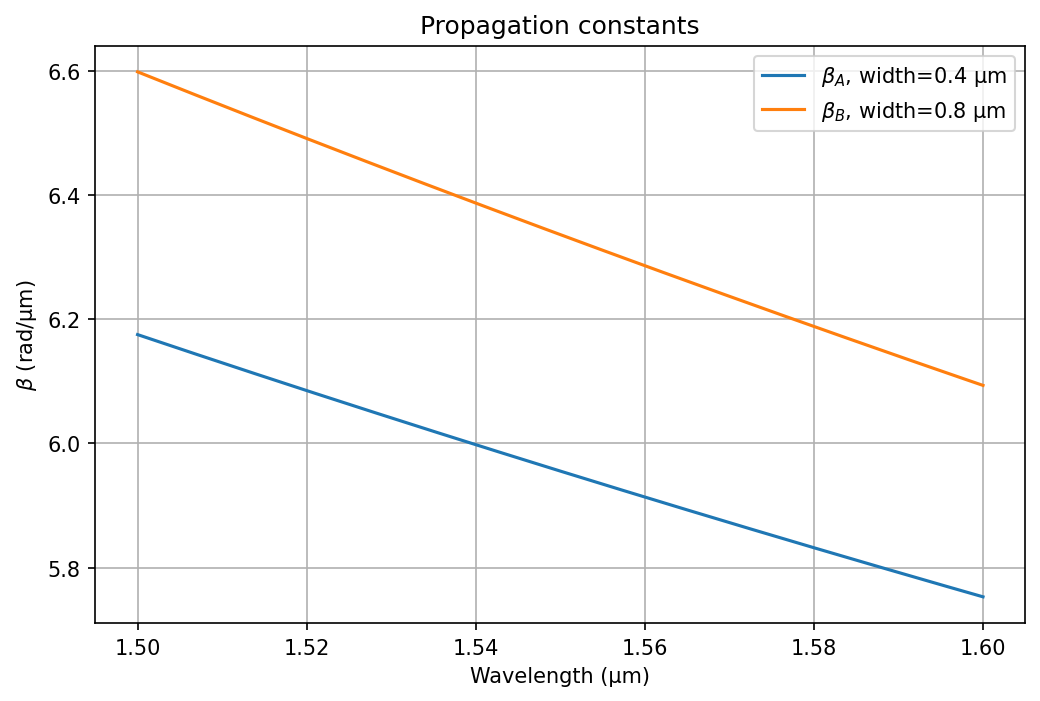

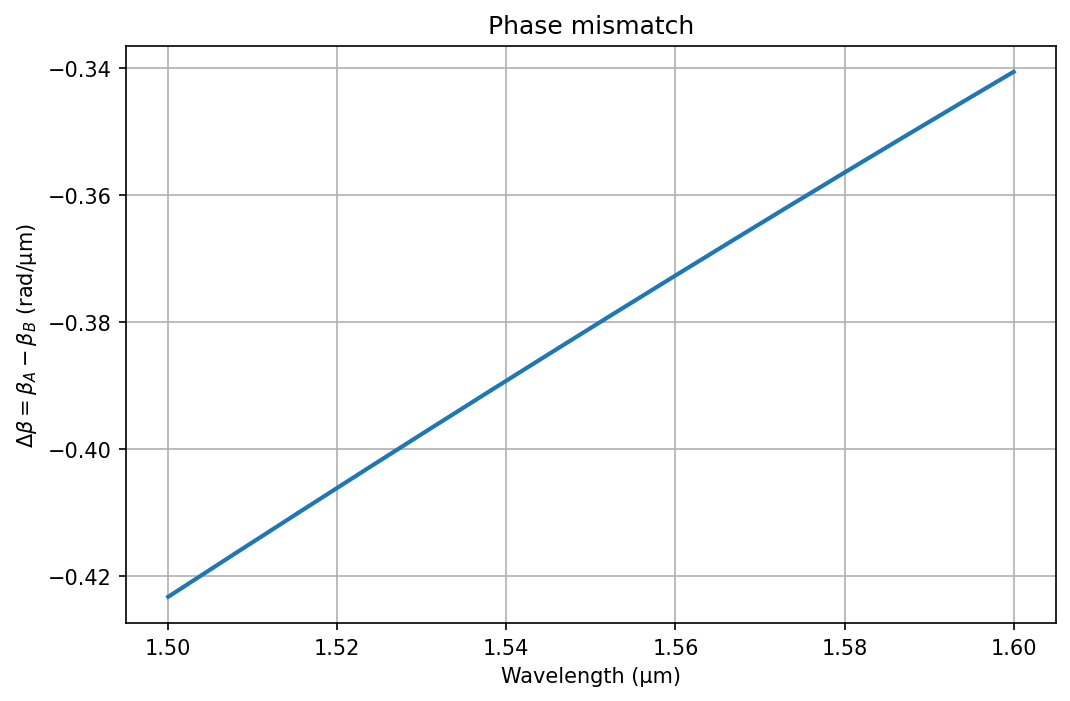

In [12]:
lambda_min = max(beta_A_df["lambda_um"].min(), beta_B_df["lambda_um"].min())
lambda_max = min(beta_A_df["lambda_um"].max(), beta_B_df["lambda_um"].max())

lambda_grid = np.linspace(lambda_min, lambda_max, 500)

plt.figure()
plt.plot(lambda_grid, beta_A_func(lambda_grid), label=rf"$\beta_A$, width={width_A_um} µm")
plt.plot(lambda_grid, beta_B_func(lambda_grid), label=rf"$\beta_B$, width={width_B_um} µm")
plt.xlabel("Wavelength (µm)")
plt.ylabel(r"$\beta$ (rad/µm)")
plt.title("Propagation constants")
plt.legend()
plt.show()

## Plot delta beta
plt.figure()
plt.plot(lambda_grid, delta_beta_func(lambda_grid), linewidth=2)
plt.xlabel("Wavelength (µm)")
plt.ylabel(r"$\Delta\beta = \beta_A - \beta_B$ (rad/µm)")
plt.title("Phase mismatch")
plt.show()

## Build Omega(lambda, gap) function

In [13]:
from scipy.interpolate import RegularGridInterpolator
import numpy as np

gap_col = "gap_um"
lambda_col = "lambda_um"
omega_col = "Omega_corrected_rad_per_um"

omega_df = omega_df.sort_values([gap_col, lambda_col]).copy()

gap_values = np.sort(omega_df[gap_col].unique())
lambda_values = np.sort(omega_df[lambda_col].unique())

Omega_grid = (
    omega_df.pivot(
        index=gap_col,
        columns=lambda_col,
        values=omega_col,
    )
    .loc[gap_values, lambda_values]
    .to_numpy()
)

Omega_interp = RegularGridInterpolator(
    points=(gap_values, lambda_values),
    values=Omega_grid,
    bounds_error=False,
    fill_value=None,
)

def Omega_func(lambda_um, gap_um):
    lambda_arr = np.asarray(lambda_um, dtype=float)
    gap_arr = np.asarray(gap_um, dtype=float)

    lambda_b, gap_b = np.broadcast_arrays(lambda_arr, gap_arr)

    points = np.column_stack([
        gap_b.ravel(),
        lambda_b.ravel(),
    ])

    out = Omega_interp(points).reshape(lambda_b.shape)

    if out.shape == ():
        return float(out)

    return out

## Define kappa(lambda, gap)


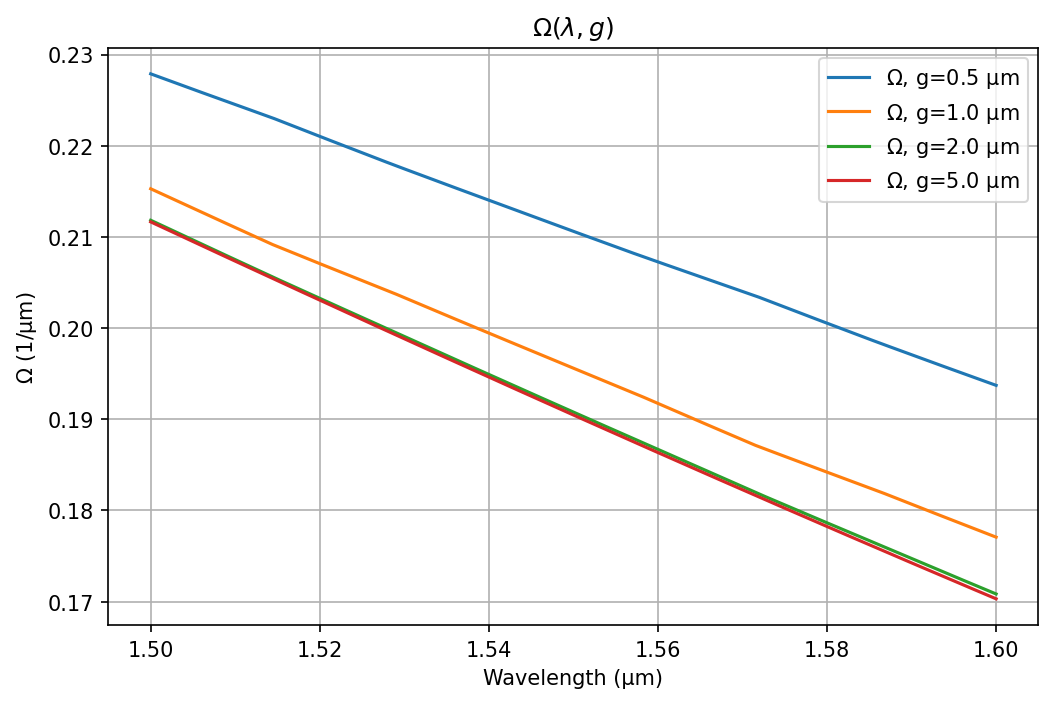

In [14]:
def kappa_func(lambda_um, gap_um):
    Omega = Omega_func(lambda_um, gap_um)
    delta_beta = delta_beta_func(lambda_um)

    inside = Omega**2 - (delta_beta**2) / 4

    # Avoid numerical negative values from interpolation noise
    inside = np.maximum(inside, 0)

    return np.sqrt(inside)

## Test Omega and kappa for a few gaps
test_gaps_um = [0.5, 1.0, 2.0, 5.0]

plt.figure()

for g in test_gaps_um:
    plt.plot(lambda_grid, Omega_func(lambda_grid, g), label=rf"$\Omega$, g={g} µm")

plt.xlabel("Wavelength (µm)")
plt.ylabel(r"$\Omega$ (1/µm)")
plt.title(r"$\Omega(\lambda,g)$")
plt.legend()
plt.show()


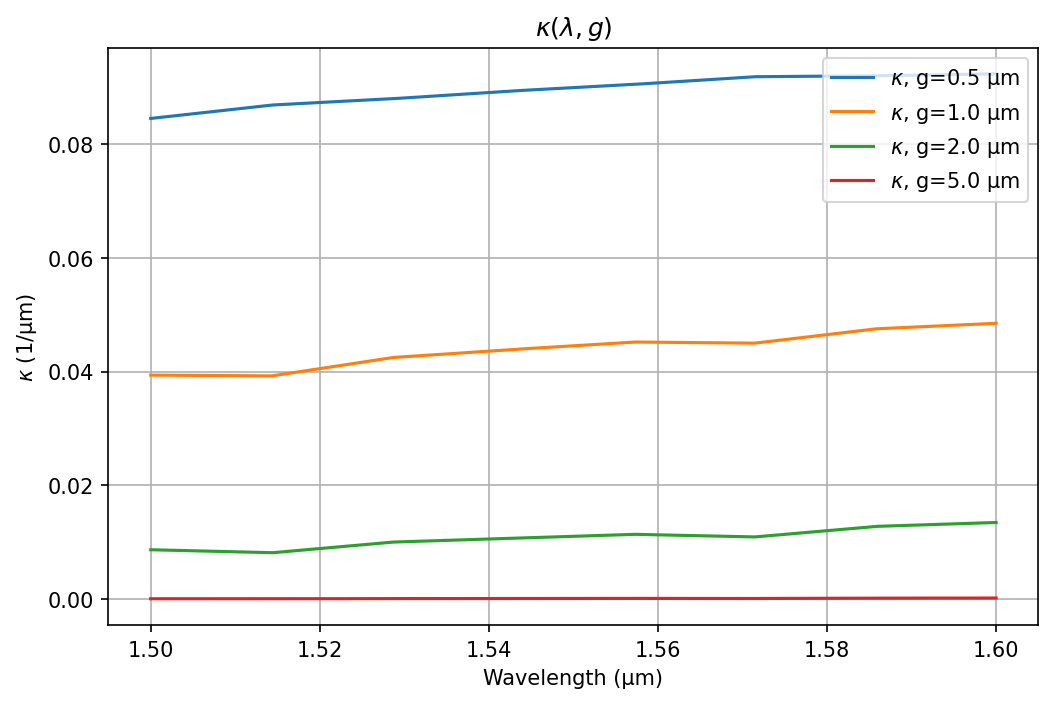

In [15]:
plt.figure()

for g in test_gaps_um:
    plt.plot(lambda_grid, kappa_func(lambda_grid, g), label=rf"$\kappa$, g={g} µm")

plt.xlabel("Wavelength (µm)")
plt.ylabel(r"$\kappa$ (1/µm)")
plt.title(r"$\kappa(\lambda,g)$")
plt.legend()
plt.show()

## Define single coupling transmission amplitude

In [16]:
def tau_func(lambda_um, gap_um, length_um):
    Omega = Omega_func(lambda_um, gap_um)
    kappa = kappa_func(lambda_um, gap_um)

    return (kappa / Omega) * np.sin(Omega * length_um)

## Define full cascade transfer function

In [17]:
def cascade_transfer(lambda_um, gaps_um, lengths_um):
    gaps_um = np.asarray(gaps_um, dtype=float)
    lengths_um = np.asarray(lengths_um, dtype=float)

    if len(gaps_um) != len(lengths_um):
        raise ValueError("gaps_um and lengths_um must have the same length.")

    A_out = np.ones_like(np.asarray(lambda_um), dtype=complex)

    for g, L in zip(gaps_um, lengths_um):
        tau_i = tau_func(lambda_um, g, L)
        A_out *= tau_i

    T = np.abs(A_out)**2
    return T

## Input design parameters

In [25]:
N = 4

gaps_um = np.array([0.8, 1.2, 2.0, 3.0])
lengths_um = np.array([50, 80, 120, 160])

assert len(gaps_um) == N
assert len(lengths_um) == N

## Compute and plot transfer function

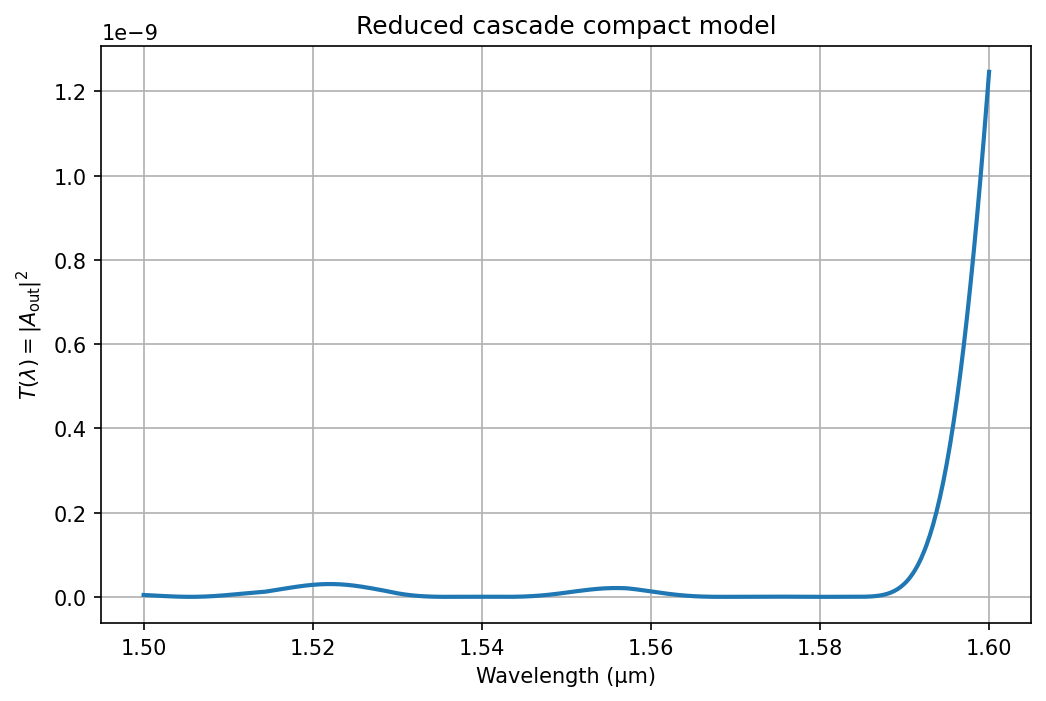

In [26]:
T = cascade_transfer(lambda_grid, gaps_um, lengths_um)

plt.figure()
plt.plot(lambda_grid, T, linewidth=2)
plt.xlabel("Wavelength (µm)")
plt.ylabel(r"$T(\lambda)=|A_\mathrm{out}|^2$")
plt.title("Reduced cascade compact model")
plt.show()

## Plot in dB

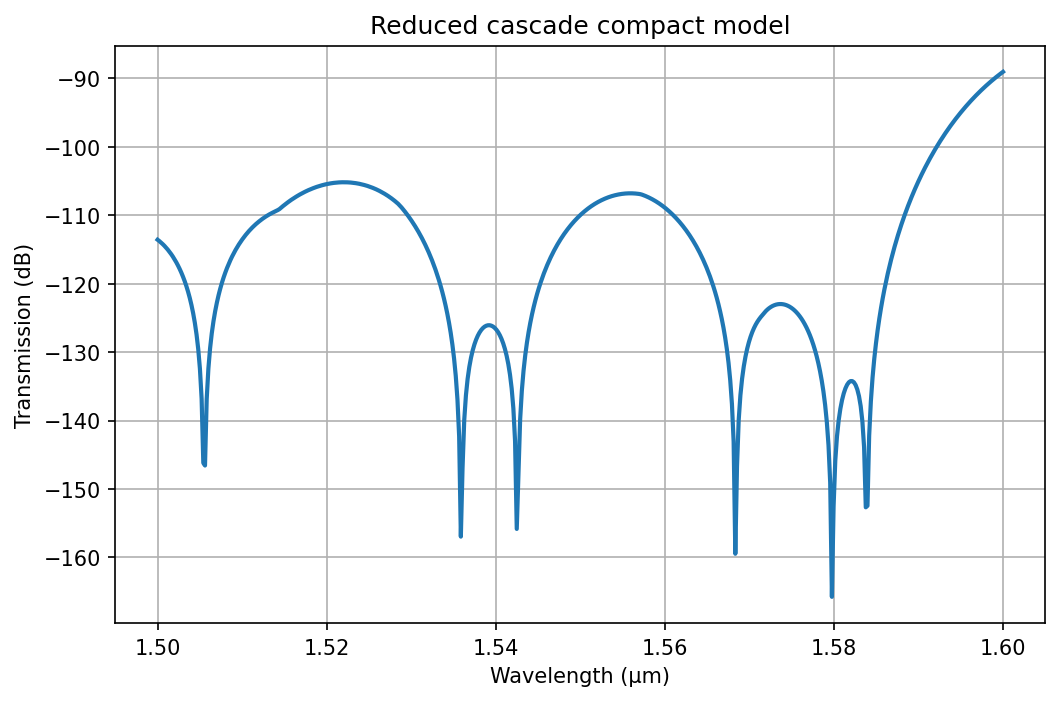

In [27]:
T_dB = 10 * np.log10(np.maximum(T, 1e-20))

plt.figure()
plt.plot(lambda_grid, T_dB, linewidth=2)
plt.xlabel("Wavelength (µm)")
plt.ylabel("Transmission (dB)")
plt.title("Reduced cascade compact model")
plt.show()